# Pool Ball Detection - Task 1

## Step 1: Initialization and Data Loading
This section imports the allowed libraries and loads the pool table images specified in the input JSON file.

### 1.1 Load Libraries

In [4]:
import json
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt


### 1.2 Data Ingestion
Reads the JSON input and loads images into a dictionary, converting them to RGB.

In [5]:
json_file = "input.json" 
loaded_images = {}

with open(json_file, 'r') as f:
    data = json.load(f)

image_list = data.get("image_path", []) if isinstance(data, dict) else data

for full_path in image_list:
    img_bgr = cv2.imread(full_path)
    
    if img_bgr is not None:
        clean_name = os.path.basename(full_path)
        
        loaded_images[clean_name] = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Loaded {len(loaded_images)} images.")

Loaded 50 images.


### 1.3 Sanity Check
Displays 3 random images to verify everything loaded correctly.

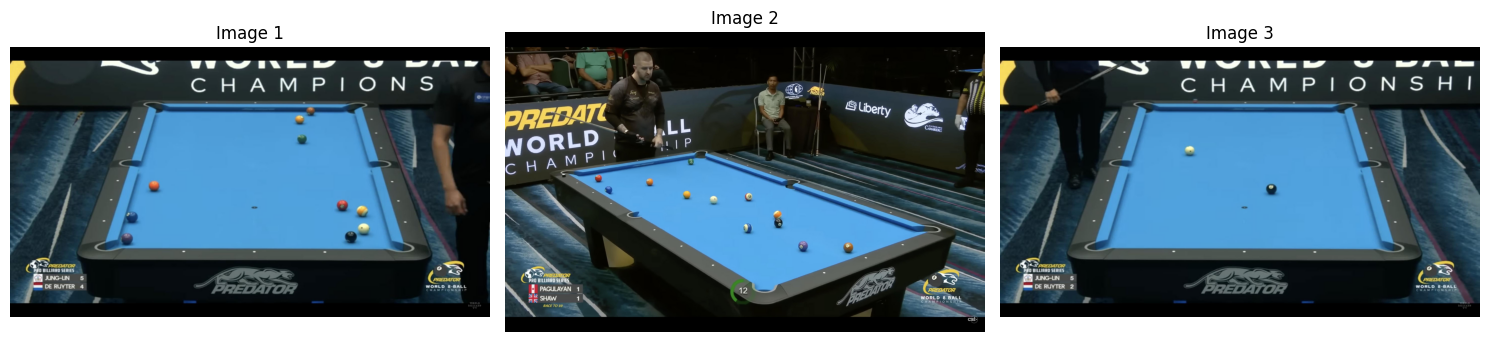

In [6]:
image_paths = list(loaded_images.keys())

first_three_images = image_paths[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
i = 1
for ax, key in zip(axes, first_three_images):
    ax.imshow(loaded_images[key])
    ax.set_title(f"Image {i}", color='black')
    ax.axis('off')
    i += 1

plt.tight_layout()
plt.show()

### 1.4 Define Test Image Variable

In [7]:
test_key = random.choice(image_paths)  
test_img = loaded_images[test_key]

# User labeling

In [ ]:
import json
import cv2
import os

def save_labels_to_dataset(new_entry, dataset_path="dataset_labels.json"):
    """
    Appends labeled data to a global dataset JSON file.
    """

    # If file exists → load it
    if os.path.exists(dataset_path):
        with open(dataset_path, "r") as f:
            data = json.load(f)
    else:
        data = {"images": []}

    # Remove existing entry for same image (avoid duplicates)
    data["images"] = [img for img in data["images"] if img["image"] != new_entry["image"]]

    # Append new one
    data["images"].append(new_entry)

    # Save back
    with open(dataset_path, "w") as f:
        json.dump(data, f, indent=4)

    print(f"✅ Added/Updated entry in {dataset_path}")

## Step 2: Top Down View

### 2.1 Table Area Detection
To warp the image, we first need to isolate the playing surface from the background. Instead of hardcoding colors, this function dynamically samples the color at the center of the image. It then uses computer vision techniques (dilation, convex hulls, and erosion) to swallow up the pool balls, straighten the pocket edges, and output a clean, solid mask of just the playable area.


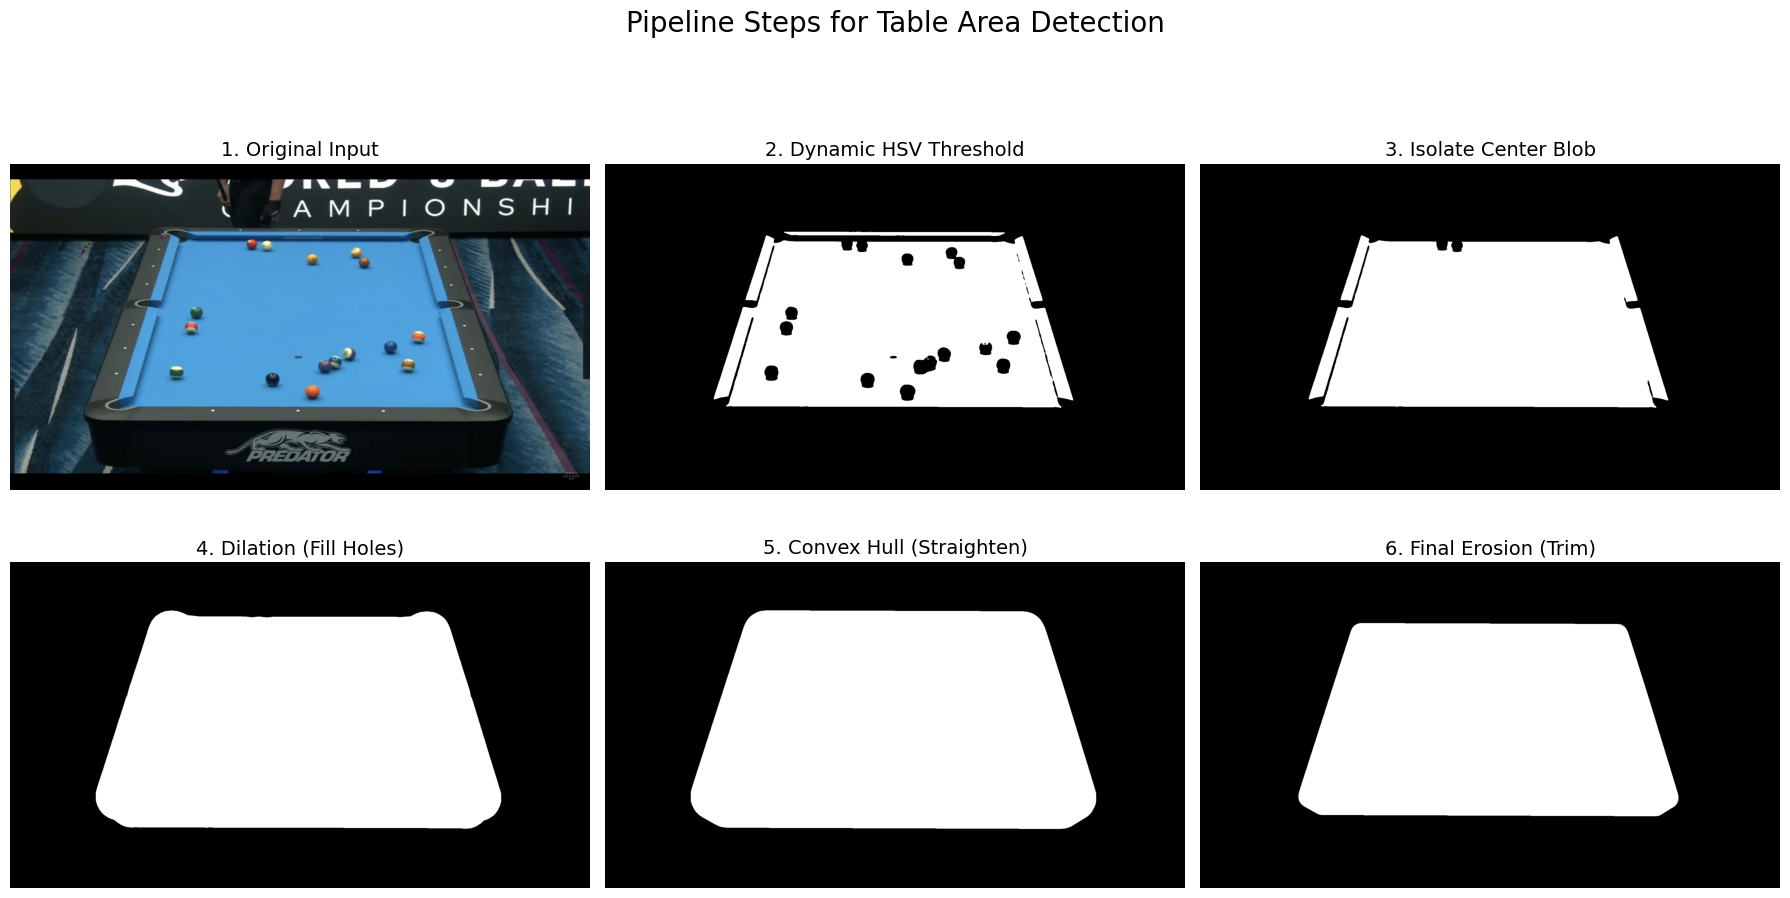

In [8]:
mask_steps = {}
# Function to get the table area
def get_table_mask(image_rgb):
    # Samples the color of the center pixel to create a mask of the table, then refines it by``
    # filling internal gaps, and wrapping it in a convex polygon.
    mask_steps['0_original'] = image_rgb.copy()
    
    img_h, img_w = image_rgb.shape[:2]
    
    # Blur to reduce noise and convert to HSV for color isolation
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    
    cx, cy = img_w // 2, img_h // 2

    # 1. Dynamic Color Sampling
    # Define rectangular patch size from image dimensions 
    patch_h = int(img_h * 0.1) 
    patch_w = int(img_w * 0.2)
    
    # Grab the dynamic rectangular patch around the center pixel
    center_patch = hsv[cy - patch_h : cy + patch_h, cx - patch_w : cx + patch_w]
    
    # Calculate the median Hue, Saturation, and Value of the center cloth
    h_med = int(np.median(center_patch[:, :, 0]))
    s_med = int(np.median(center_patch[:, :, 1]))
    v_med = int(np.median(center_patch[:, :, 2]))

    # Create a tight boundary around that specific median color
    lower_bound = (max(0, h_med - 12), max(60, s_med - 50), max(100, v_med - 60))
    upper_bound = (min(180, h_med + 12), 255, 255)
    
    raw_cloth_mask = cv2.inRange(hsv, lower_bound, upper_bound)

    mask_steps['1_hsv_threshold'] = raw_cloth_mask.copy()
    
    # 2. Isolate the True Table Blob
    contours, _ = cv2.findContours(raw_cloth_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros((img_h, img_w), dtype=np.uint8)

    table_contour = None
    
    # Check the 5 largest blobs. Pick the one that covers the center pixel.
    largest_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]
    for contour in largest_contours:
        if cv2.pointPolygonTest(contour, (cx, cy), False) >= 0:
            table_contour = contour
            break
            
    # Fallback: If center is somehow missed (e.g., covered by a ball), pick the largest blob
    if table_contour is None:
        table_contour = max(contours, key=cv2.contourArea)

    isolated_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(isolated_mask, [table_contour], -1, 255, cv2.FILLED)
    
    mask_steps['2_isolated_center_blob'] = isolated_mask.copy()

    # 3. Dilation (Fill Holes)
    # Draw the raw contour onto a blank canvas
    working_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(working_mask, [table_contour], -1, 255, cv2.FILLED)
    

    # Grow the white pixels to swallow balls and shadows
    kernel_size = max(25, img_w // 50)
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size*2+1, kernel_size*2+1))
    working_mask = cv2.dilate(working_mask, dilation_kernel, iterations=2)

    mask_steps['3_dilated_solid_blob'] = working_mask.copy()
    
    # 4. Convex Hull (Straighten Edges)
    contours_dilated, _ = cv2.findContours(working_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_dilated = max(contours_dilated, key=cv2.contourArea)
    
    
    hull = cv2.convexHull(largest_dilated)
    
    solid_polygon_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(solid_polygon_mask, [hull], 255)

    mask_steps['4_geometric_convex_hull'] = solid_polygon_mask.copy()
    
    # 5. Erosion (Make edges Sharper by removing a small border)
    erosion_padding = max(4, int(min(img_h, img_w) * 0.020))
    erosion_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erosion_padding*2+1, erosion_padding*2+1))
    final_table_mask = cv2.erode(solid_polygon_mask, erosion_kernel, iterations=2)
    
    mask_steps['5_final_eroded_surface'] = final_table_mask.copy()
    
    return final_table_mask

# ═══════════════════════════════════════════════════════════════
#  Visualization Pipeline
# ═══════════════════════════════════════════════════════════════

final_mask = get_table_mask(test_img)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel() 

step_keys = sorted(mask_steps.keys())

titles = [
    "1. Original Input",
    "2. Dynamic HSV Threshold",
    "3. Isolate Center Blob",
    "4. Dilation (Fill Holes)",
    "5. Convex Hull (Straighten)",
    "6. Final Erosion (Trim)"
]

for i in range(len(step_keys)):
    key = step_keys[i]
    display_img = mask_steps[key]
    
    if len(display_img.shape) == 3: 
        axes[i].imshow(display_img)
    else: 
        axes[i].imshow(display_img, cmap='gray')
        
    axes[i].set_title(titles[i], color='black', fontsize=14)
    axes[i].axis('off') 

plt.suptitle("Pipeline Steps for Table Area Detection", fontsize=20, color='black')
plt.tight_layout(rect=[0, 0.01, 1, 0.96]) 
plt.show()


### 2.1.1 Check Mask Overlay

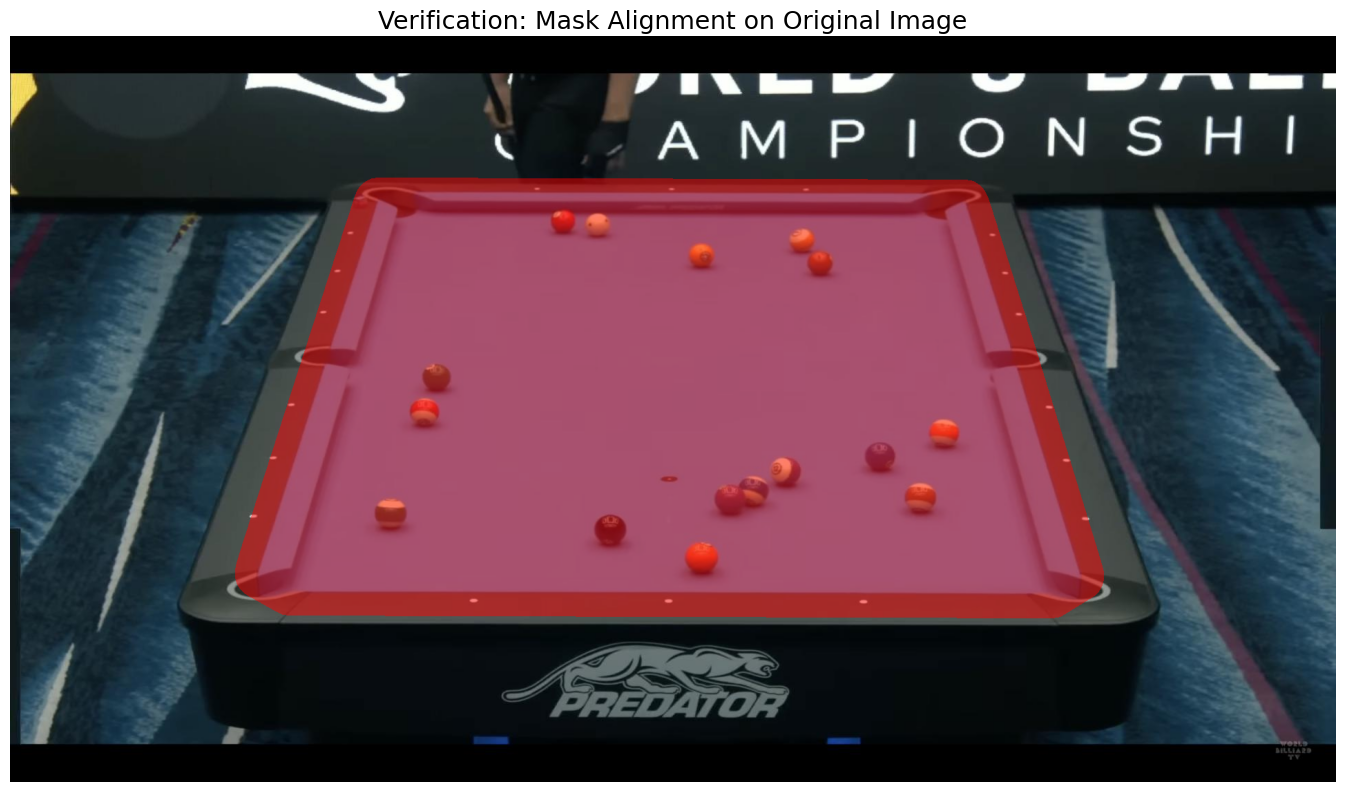

In [9]:
# Red Verification Overlay 
red_layer = np.zeros_like(test_img)
red_layer[:] = (255, 0, 0) 

blended_img = cv2.addWeighted(test_img, 0.5, red_layer, 0.5, 0)

overlay_img = np.where(final_mask[..., None] == 255, blended_img, test_img)

plt.figure(figsize=(14, 8))
plt.imshow(overlay_img)
plt.title("Verification: Mask Alignment on Original Image", fontsize=18, color='black')
plt.axis('off')
plt.tight_layout()
plt.show()

### 2.2 Table Corner Extraction
Because our table mask has slightly rounded corners, we cannot simply look for the "tips" of the shape. Instead, this function finds the four straight sides of the table, draws mathematically perfect lines through them, and calculates exactly where those lines cross to find the true, sharp corners.

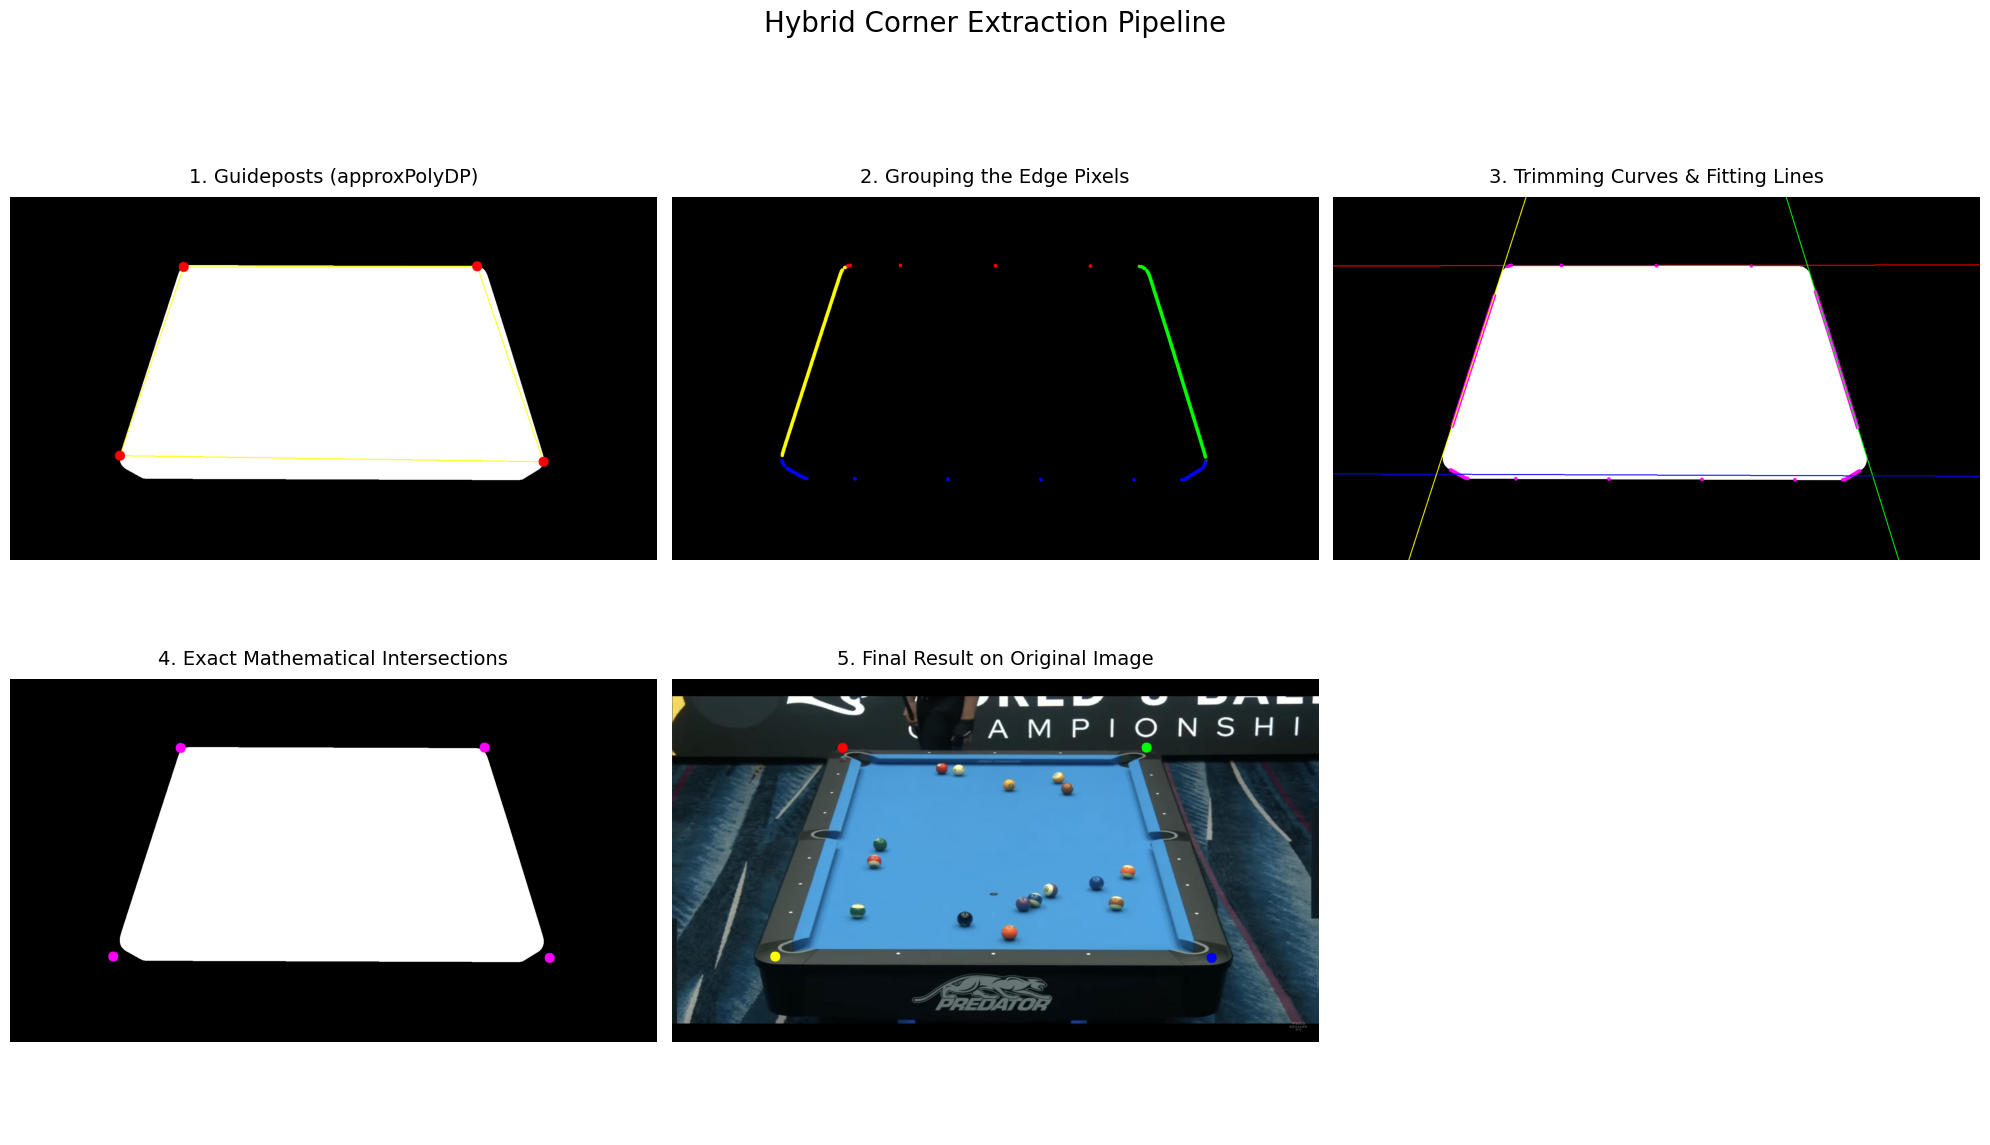

In [10]:
# ═══════════════════════════════════════════════════════════════
#  Helper Functions
# ═══════════════════════════════════════════════════════════════

# Sorts corners using the center point as reference 
def order_points_clockwise(pts):
    cx, cy = np.mean(pts, axis=0)
    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    sorted_pts = pts[np.argsort(angles)]
    
    s = sorted_pts.sum(axis=1)
    tl_index = np.argmin(s)
    return np.roll(sorted_pts, shift=-tl_index, axis=0)

# Line intersection function (returns a point if possible, None if parallel)
def intersect_lines(l1, l2):
    vx1, vy1, x1, y1 = l1
    vx2, vy2, x2, y2 = l2
    
    A1, B1 = vy1, -vx1
    C1 = vy1 * x1 - vx1 * y1
    
    A2, B2 = vy2, -vx2
    C2 = vy2 * x2 - vx2 * y2
    
    det = A1 * B2 - A2 * B1
    if abs(det) < 1e-6:
        return None 
        
    x = (C1 * B2 - C2 * B1) / det
    y = (A1 * C2 - A2 * C1) / det
    return [x, y]

def draw_infinite_line(img, line, color, thickness=2):
    vx, vy, x, y = line
    mult = 3000
    p1 = (int(x - mult * vx), int(y - mult * vy))
    p2 = (int(x + mult * vx), int(y + mult * vy))
    cv2.line(img, p1, p2, color, thickness)

corner_steps = {}

def get_corners_from_mask(table_mask):
    # For visualization purposes
    mask_rgb = cv2.cvtColor(table_mask, cv2.COLOR_GRAY2RGB)

    cnts, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
        
    largest_contour = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(largest_contour, True)
    
    # Get corner points using approxPolyDP to find 4 corners
    guide_corners = None
    for eps_multiplier in np.linspace(0.005, 0.2, 100):
        epsilon = eps_multiplier * peri
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)
        if len(approx) == 4 and cv2.isContourConvex(approx):
            guide_corners = approx.reshape(4, 2).astype("float32")
            break
            
    if guide_corners is None: return None
    
    # Order the guideposts: 0:TL, 1:TR, 2:BR, 3:BL
    ordered_guides = order_points_clockwise(guide_corners)
    
    # Image 1: Show guideposts on the mask
    step1_img = mask_rgb.copy()
    cv2.polylines(step1_img, [np.int32(ordered_guides)], True, (255, 255, 0), 2)
    for pt in ordered_guides:
        cv2.circle(step1_img, (int(pt[0]), int(pt[1])), 15, (255, 0, 0), -1)
    corner_steps['1_guideposts'] = step1_img


    pts = largest_contour.reshape(-1, 2)
    edge_points = [[], [], [], []]
    
    # Assign every pixel to one of the 4 edges
    for pt in pts:
        min_dist = float('inf')
        best_edge = -1
        for i in range(4):
            p1 = ordered_guides[i]
            p2 = ordered_guides[(i + 1) % 4]
            l2 = np.sum((p1 - p2)**2)
            if l2 == 0: continue
            t = max(0, min(1, np.dot(pt - p1, p2 - p1) / l2))
            proj = p1 + t * (p2 - p1)
            dist = np.linalg.norm(pt - proj)
            if dist < min_dist:
                min_dist = dist
                best_edge = i
        edge_points[best_edge].append(pt)
    
    # Image 2: Show edge pixels colored by assigned edge
    step2_img = np.zeros_like(mask_rgb)
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)] 
    for i in range(4):
        for pt in edge_points[i]:
            cv2.circle(step2_img, tuple(pt), 5, colors[i], -1)
    corner_steps['2_edge_pixels'] = step2_img


    # Fit a line to each edge
    fitted_lines = []
    step3_img = mask_rgb.copy()
    
    for i in range(4):
        ep = np.array(edge_points[i])
        if len(ep) < 10: return None
        
        p1 = ordered_guides[i]
        dists = np.linalg.norm(ep - p1, axis=1)
        ep_sorted = ep[np.argsort(dists)]
        
        trim = int(len(ep_sorted) * 0.15)
        if trim > 0:
            ep_trimmed = ep_sorted[trim:-trim]
        else:
            ep_trimmed = ep_sorted
        for pt in ep_trimmed:
            cv2.circle(step3_img, tuple(pt), 5, (255, 0, 255), -1)
            
        [vx, vy, x, y] = cv2.fitLine(ep_trimmed, cv2.DIST_L2, 0, 0.01, 0.01)
        line = (vx[0], vy[0], x[0], y[0])
        fitted_lines.append(line)
        
        draw_infinite_line(step3_img, line, colors[i], 2)
        
    # Image 3: Show fitted lines on the mask
    corner_steps['3_fitted_lines'] = step3_img

    # Intersect the 4 lines to get the new corners
    tl = intersect_lines(fitted_lines[0], fitted_lines[3]) # Top intersects Left
    tr = intersect_lines(fitted_lines[0], fitted_lines[1]) # Top intersects Right
    br = intersect_lines(fitted_lines[1], fitted_lines[2]) # Right intersects Bottom
    bl = intersect_lines(fitted_lines[2], fitted_lines[3]) # Bottom intersects Left
    
    if None in (tl, tr, br, bl): return None
    
    step4_img = mask_rgb.copy()

    final_corners = np.array([tl, tr, br, bl], dtype="float32")
    
    for pt in final_corners:
        cv2.circle(step4_img, (int(pt[0]), int(pt[1])), 15, (255, 0, 255), -1)
    corner_steps['4_intersections'] = step4_img

    return final_corners



#  Run the Visualization

test_mask = get_table_mask(test_img)

raw_corners = get_corners_from_mask(test_mask)

if raw_corners is not None:
    ordered_corners = order_points_clockwise(raw_corners)
    
    final_display_img = test_img.copy()
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)] 
    for i, pt in enumerate(ordered_corners):
        cv2.circle(final_display_img, (int(pt[0]), int(pt[1])), 15, colors[i], -1)
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel() 
    
    titles = [
        "1. Guideposts (approxPolyDP)", 
        "2. Grouping the Edge Pixels", 
        "3. Trimming Curves & Fitting Lines", 
        "4. Exact Mathematical Intersections",
        "5. Final Result on Original Image"
    ]
    
    images_to_show = [
        corner_steps['1_guideposts'], 
        corner_steps['2_edge_pixels'], 
        corner_steps['3_fitted_lines'], 
        corner_steps['4_intersections'],
        final_display_img
    ]
    
    for i in range(5):
        axes[i].imshow(images_to_show[i])
        axes[i].set_title(titles[i], color='black', fontsize=14, pad=10)
        axes[i].axis('off')

    axes[5].axis('off')

    plt.suptitle("Hybrid Corner Extraction Pipeline", fontsize=20, color='black')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Could not find corners to visualize.")

### 2.3 Table Warping Pipeline

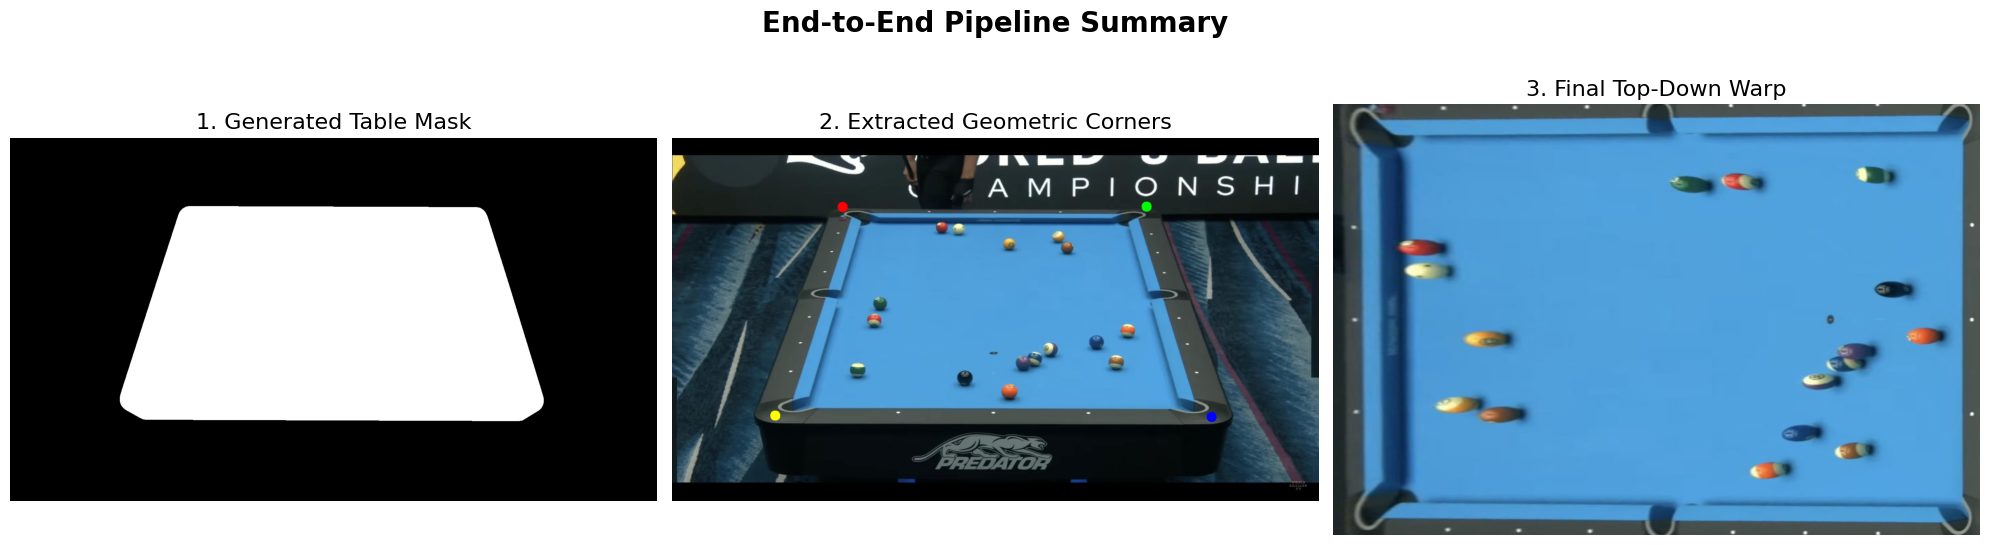

In [11]:
# Warps the 4 corners into an horizontal top-down view.
# Returns the warped image AND the transformation matrix (M) needed for backtracking.
def warp_to_top_down(image_rgb, ordered_corners, width=1200, height=800):
    top_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[1])
    left_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[3])
    
    ratio = top_edge / left_edge
    
    if ratio < 1.8:
        # END-VIEW mapping
        dst_pts = np.array([
            [0, 0],                  
            [0, height - 1],         
            [width - 1, height - 1], 
            [width - 1, 0]           
        ], dtype="float32")
    else:
        # SIDE-VIEW mapping
        dst_pts = np.array([
            [0, 0],                  
            [width - 1, 0],          
            [width - 1, height - 1], 
            [0, height - 1]          
        ], dtype="float32")

    # M is the mathematical map from Original -> Flat
    M = cv2.getPerspectiveTransform(ordered_corners, dst_pts)

    warped = cv2.warpPerspective(image_rgb, M, (width, height), borderMode=cv2.BORDER_REPLICATE)
    
    return warped, M

test_mask = get_table_mask(test_img)

raw_corners = get_corners_from_mask(test_mask)

if raw_corners is not None:
    ordered_corners = order_points_clockwise(raw_corners)

corner_img = test_img.copy()
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
for i, pt in enumerate(ordered_corners):
    cv2.circle(corner_img, (int(pt[0]), int(pt[1])), 15, colors[i], -1)
    
warped_img, warped_Mtx = warp_to_top_down(test_img, ordered_corners)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.imshow(test_mask, cmap='gray')
ax1.set_title("1. Generated Table Mask", fontsize=16, color='black')
ax1.axis('off')

ax2.imshow(corner_img)
ax2.set_title("2. Extracted Geometric Corners", fontsize=16, color='black')
ax2.axis('off')

ax3.imshow(warped_img)
ax3.set_title("3. Final Top-Down Warp", fontsize=16, color='black')
ax3.axis('off')

plt.suptitle("End-to-End Pipeline Summary", fontsize=20, weight='bold', color='black')
plt.tight_layout()
plt.show()

### 2.4 Save Table Warping Images

In [12]:
save_outputs = False

if save_outputs:
    # Save warped images
    output_folder = "output"
    os.makedirs(output_folder, exist_ok=True)

    print(f"Starting batch process. Saving top-down images to '{output_folder}'...")

    success_count = 0
    fail_count = 0

    homography_matrices = {}

    for filename, img_rgb in loaded_images.items():
        test_mask = get_table_mask(img_rgb)
        raw_corners = get_corners_from_mask(test_mask)
        
        if raw_corners is not None:
            ordered_corners = order_points_clockwise(raw_corners)
            
            warped_img, M = warp_to_top_down(img_rgb, ordered_corners)
            
            homography_matrices[filename] = M
            
            warped_bgr = cv2.cvtColor(warped_img, cv2.COLOR_RGB2BGR)
            save_path = os.path.join(output_folder, filename)
            cv2.imwrite(save_path, warped_bgr)
            
            success_count += 1
        else:
            print(f"Warning: Could not find corners for {filename}")
            fail_count += 1

    print(f"Batch complete! Warped {success_count} images. ({fail_count} failed)")
    print(f"Successfully saved {len(homography_matrices)} matrices for backtracking.")

# Other

In [13]:
import matplotlib.pyplot as plt

def debug_ball_analysis(roi_bgr, valid_mask, white_mask_2d, ball_id, conf, stats):
    """
    Visualizes the steps of the ball identification process.
    """
    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    fig.suptitle(f"Debug Analysis: Ball Candidate {ball_id} (Confidence: {conf:.2f})\n"
                 f"H:{stats['hsv'][0] if stats['hsv'] is not None else 'N/A':.1f} "
                 f"Stripe:{stats['is_stripe']} (Spread:{stats['spread_bool']})", fontsize=12)

    # 1. Original Crop
    axes[0].imshow(roi_rgb)
    axes[0].set_title("Original ROI")

    # 3. Valid Pixels (After removing cloth, glare, shadows)
    # Showing the ROI only where valid_mask is True
    valid_viz = roi_rgb.copy()
    valid_viz[~valid_mask] = [0, 0, 0] # Black out invalid
    axes[1].imshow(valid_viz)
    axes[1].set_title("Filtered Ball Pixels")

    # 4. White Detection (For Stripes)
    axes[2].imshow(white_mask_2d, cmap='bone')
    axes[2].set_title("Detected White Path")

    for ax in axes:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [30]:
import cv2
import numpy as np

# ─── Pool ball colour definitions (HSV) ──────────────────────────────────────
# Each entry: (ball_number, name, hue_low, hue_high, sat_min, val_min, val_max)
# Ball  0 = cue ball (white)
# Balls 1–7  = solid colours
# Ball  8    = black
# Balls 9–15 = same colours as 1–7 but striped (>40% white pixels)

BALL_PROFILES = [
    # num  name        hL   hH   sMin  vMin  vMax
    # Yellow: Adjusted hL down to 15 based on your 15;181;161 sample
    (1,  "yellow",     15,  30,   110,  140,  255),
    
    # Blue: Very stable in your data around 104-110
    (2,  "blue",       100, 115,  170,  90,   150),
    
    # RED SPLIT 1: The low end of the HSV cylinder
    (3,  "red_low",       0,   8,  120,  110, 220), 
    
    # RED SPLIT 2: The high end (wrap-around) of the HSV cylinder
    (3,  "red_high",    165, 180,  120,  110, 220), 
    
    # Purple: Your data shows Hue 110-124, which is very close to Blue. 
    # Key difference is lower Saturation (70-140) compared to Blue (190+)
    (4,  "purple",     110, 125,  70,   100,  140),
    
    # Orange: Very high Value and high Saturation
    (5,  "orange",     7,   18,   140,  140,  255),
    
    # Green: Your data shows Hue 73-92
    (6,  "green",      70,  95,   100,  60,   110),
    
    # Maroon/Brown: Low Value is the defining factor here
    (7,  "maroon",     10,  25,   110,  90,   145),
    
    # Black: Ignore Hue (it reflects the table), focus on very low Value
    (8,  "black",      0,   180,  0,    0,    75),
]
STRIPE_OFFSET = 8   # ball 9 = ball 1 + 8, etc.
WHITE_BALL_ID = 0


# ─── Helpers ─────────────────────────────────────────────────────────────────

def _extract_ball_roi(img_bgr: np.ndarray, cx: float, cy: float, r: float) -> np.ndarray:
    """Return a tight square crop (BGR) around the ball, zero-padded if near edge."""
    x, y, rad = int(round(cx)), int(round(cy)), int(round(r))
    h, w = img_bgr.shape[:2]
    x1, y1 = max(x - rad, 0), max(y - rad, 0)
    x2, y2 = min(x + rad, w),  min(y + rad, h)
    return img_bgr[y1:y2, x1:x2].copy()


def _circular_mask(roi: np.ndarray, cx: float, cy: float, r: float) -> np.ndarray:
    """Boolean mask — True inside the circle, clipped to roi dimensions."""
    rh, rw = roi.shape[:2]
    Y, X = np.ogrid[:rh, :rw]
    rad = int(round(r))
    return (X - rad) ** 2 + (Y - rad) ** 2 <= rad ** 2


def _adaptive_white_threshold(roi_hsv, mask):
    ball_pixels = roi_hsv[mask]
    if len(ball_pixels) == 0:
        return 60, 180

    vals = ball_pixels[:, 2]
    # Use a lower percentile (70th instead of 90th) to get a 
    # better sense of the 'average' bright part, not just the peak glare.
    ref_val = np.percentile(vals, 70)

    # Lower the minimum val_thresh. 150 is often too high for 
    # balls in the shadow of the table rail.
    val_thresh = max(120, ref_val * 0.7) 
    sat_thresh = 65 # Loosen this to catch 'tinted' whites

    return sat_thresh, val_thresh


def _pixel_stats(roi_bgr: np.ndarray, mask: np.ndarray, debug=False):
    """
    Analyzes ball ROI using a 'Core Mask' for color and a 'Full Mask' for stripes.
    Removes shadows and table reflections that cause misclassification.
    """
    roi_hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    h_chan, s_chan, v_chan = roi_hsv[:, :, 0], roi_hsv[:, :, 1], roi_hsv[:, :, 2]
    rh, rw = roi_hsv.shape[:2]

    # --- 1. Create masks for different regions ---
    # Core mask: Small circle in the center (top-weighted) to get the "true" color
    # This avoids the blue/green table shadow at the bottom.
    Y, X = np.ogrid[:rh, :rw]
    # Shift center up slightly (0.4 instead of 0.5) to stay away from bottom shadows
    dist_from_core = np.sqrt((X - rw * 0.5)**2 + (Y - rh * 0.4)**2)
    core_mask = dist_from_core < (rw * 0.25) # 25% radius core

    # --- 2. Filter out Glare, Deep Shadows, and Table Bleed ---
    # Glare is usually white/high value. Shadows are low value.
    # Table bleed usually has low saturation or very specific hue.
    glare_mask = (v_chan > 240) & (s_chan < 30)
    shadow_mask = (v_chan < 50) # Bottom of the ball is often < 50
    
    # Valid pixels for stripe/ratio analysis (Full ball minus edge noise)
    valid_mask = mask & (~glare_mask) & (~shadow_mask)
    
    valid_pixels = roi_hsv[valid_mask]
    if valid_pixels.size == 0:
        return (0.0, 0.0, None, 0.0, False), (None, None) if debug else (0.0, 0.0, None, 0.0, False)

    # --- 3. Adaptive White Detection ---
    sat_thresh, val_thresh = _adaptive_white_threshold(roi_hsv, valid_mask)
    # Be slightly more generous with white detection to catch stripes in shadow
    is_white_1d = (valid_pixels[:, 1] < (sat_thresh + 10)) & (valid_pixels[:, 2] > (val_thresh - 20))
    white_ratio = float(is_white_1d.sum()) / len(valid_pixels)

    # Step 4 ---
    stripe_by_spread = False
    temp_white_mask = np.zeros(roi_hsv.shape[:2], dtype=bool)
    temp_white_mask[valid_mask] = is_white_1d
    
    white_coords = np.column_stack(np.where(temp_white_mask))
    if len(white_coords) > 15: 
        y_min, x_min = white_coords.min(axis=0)
        y_max, x_max = white_coords.max(axis=0)
        
        # NEW: Check vertical distribution
        # If the 'center of mass' of the white is very high, it's likely overhead glare
        avg_y = np.mean(white_coords[:, 0])
        is_glare_top = avg_y < (rh * 0.35) 
        
        max_span = max(y_max - y_min, x_max - x_min)
        
        # Only allow Stripe if it's NOT just a top-heavy glare
        if max_span > (rh * 0.75) and white_ratio > 0.15 and not is_glare_top:
            stripe_by_spread = True

    # --- 5. Colored Pixel Analysis (The CORE Method) ---
    # For Color ID, we ONLY look at the core pixels that aren't white
    # This is the most robust way to ignore table reflections.
    core_valid_mask = valid_mask & core_mask
    core_pixels = roi_hsv[core_valid_mask]
    
    # Filter white pixels out of the core for median calculation
    is_white_core = (core_pixels[:, 1] < sat_thresh) & (core_pixels[:, 2] > val_thresh)
    colored_core = core_pixels[~is_white_core]

    if colored_core.size > 10:
        median_hsv = np.median(colored_core, axis=0)
    else:
        # Fallback to general valid pixels if core is too small (e.g., edge of frame)
        colored_general = valid_pixels[~is_white_1d]
        median_hsv = np.median(colored_general, axis=0) if colored_general.size > 0 else None

    colored_ratio = 1.0 - white_ratio
    sat_spread = float(np.percentile(valid_pixels[:, 1], 75) - 
                       np.percentile(valid_pixels[:, 1], 25))
    
    white_mask_2d = (temp_white_mask.astype(np.uint8)) * 255
    
    stats = (white_ratio, colored_ratio, median_hsv, sat_spread, stripe_by_spread)
    
    if debug:
        return stats, (valid_mask, white_mask_2d)

    return stats

# def _best_profile(median_hsv, white_ratio, sat_spread, colored_ratio, stripe_by_spread):
#     """
#     Logic-heavy decision making to prevent cue-ball/8-ball mixups.
#     """
#     if median_hsv is None:
#         return 8, False # No color = Black ball

#     h, s, v = float(median_hsv[0]), float(median_hsv[1]), float(median_hsv[2])

#     # 1. Aggressive Cue Ball Check
#     # High value + low saturation = Cue ball. 
#     # Or if white_ratio is extremely high (>70%)
#     if (v > 170 and s < 60) or (white_ratio > 0.75):
#         return 0, False

#     # 2. Aggressive Black Ball Check
#     # If the core is dark and lacks saturation
#     if v < 75 and s < 60:
#         return 8, False

#     # 3. Standard Colored Ball Matching
#     best_num, best_score = 8, float("inf")
#     for profile in BALL_PROFILES:
#         if profile[0] == 8: continue
#         sc = _score_profile(h, s, v, profile)
#         if sc < best_score:
#             best_score, best_num = sc, profile[0]

#     # 4. Stripe Logic
#     stripe = _is_stripe(white_ratio, sat_spread, colored_ratio, stripe_by_spread)
    
#     return best_num, stripe

# def _is_stripe(white_ratio, sat_spread, colored_ratio, stripe_by_spread):
#     """
#     Refined stripe detection.
#     """
#     # If spatial spread is true AND we have a decent amount of white
#     if stripe_by_spread and white_ratio > 0.18:
#         return True
    
#     # Heuristic score
#     stripe_score = 0.0
#     if 0.25 <= white_ratio <= 0.70: stripe_score += 2.5
#     if sat_spread > 55: stripe_score += 1.5
    
#     return stripe_score >= 3.0

'''
def _is_stripe(white_ratio, sat_spread, colored_ratio, stripe_by_spread):
    # If spatial spread is true, it's a huge bonus
    stripe_score = 3.5 if stripe_by_spread else 0.0
    
    # Only add points for white ratio if it's in the "sweet spot"
    # 0.57 (your debug image) is high, but without Spread:True, it's risky
    if 0.30 <= white_ratio <= 0.65: 
        stripe_score += 1.5
    
    if sat_spread > 60: 
        stripe_score += 1.0
        
    return stripe_score >= 3.0
'''


def _score_profile(h, s, v, profile):
    # Unpack the profile (note: name is included)
    num, name, hL, hH, sMin, vMin, vMax = profile
    
    # 1. Check if S and V are within bounds (essential for separating colors)
    if not (s >= sMin and vMin <= v <= vMax):
        return float("inf")

    # 2. Calculate the center of the hue range
    h_centre = (hL + hH) / 2
    
    # 3. Your circular distance math (Excellent)
    hue_diff = abs(h - h_centre)
    circular_hue_diff = min(hue_diff, 180 - hue_diff) 

    # 4. NEW: The "Sanity Check"
    # If the hue is more than 20 degrees away from the profile center, 
    # ignore this profile. This replaces the strict hL/hH check.
    if circular_hue_diff > 20:
        return float("inf")

    # 5. Score based on circular distance and saturation
    # We prioritize hue, then saturation (higher saturation = better score)
    score = circular_hue_diff + (255 - s) * 0.1
    return score

def _is_stripe(white_ratio, sat_spread, colored_ratio, stripe_by_spread):
    """Improved stripe logic using the new spatial spread parameter."""
    # Strongest indicator: White band spans the ball diameter
    if stripe_by_spread and 0.15 < white_ratio < 0.8:
        return True
    
    stripe_score = 0.0
    if 0.22 <= white_ratio <= 0.72: stripe_score += 2.0
    if sat_spread > 50: stripe_score += 1.5
    if colored_ratio > 0.25: stripe_score += 0.5
    
    return stripe_score >= 3.0


def _best_profile(median_hsv, white_ratio, sat_spread, colored_ratio, stripe_by_spread):
    """Updated to accept and pass the stripe_by_spread flag."""
    if median_hsv is None:
        return 8, False

    h, s, v = float(median_hsv[0]), float(median_hsv[1]), float(median_hsv[2])

    if white_ratio > 0.60 or (v > 180 and s < 50):
        return WHITE_BALL_ID, False

    # --- NEW: Aggressive Black Ball Detection ---
    # If the median value is extremely low, it's the 8-ball.
    if v < 60: 
        return 8, False

    best_num, best_score = 8, float("inf")
    for profile in BALL_PROFILES:
        if profile[0] == 8: continue
        sc = _score_profile(h, s, v, profile)
        if sc < best_score:
            best_score, best_num = sc, profile[0]

    # Pass the new param to the stripe detector
    stripe = _is_stripe(white_ratio, sat_spread, colored_ratio, stripe_by_spread)
    return best_num, stripe


def _best_profile_all(median_hsv, white_ratio, sat_spread, colored_ratio, stripe_by_spread):
    """
    Returns:
        best_num        -> chosen base ball number (1–7, 8, or 0 for cue)
        stripe          -> bool
        best_score      -> score of winning profile
        second_score    -> score of runner-up profile
    """

    # --- No data fallback ---
    if median_hsv is None:
        return 8, False, float("inf"), float("inf")


    ball_scores = {i : -float("inf") for i in range(17)}

    h, s, v = float(median_hsv[0]), float(median_hsv[1]), float(median_hsv[2])

    # --- 1. Cue ball detection ---
    # if white_ratio > 0.60 or (v > 180 and s < 50):
    #     return WHITE_BALL_ID, False, 0.0, float("inf")

    # --- 2. Black ball detection ---
    # if v < 60:
    #     return 8, False, 0.0, float("inf")

    # --- 3. Profile matching with BEST + SECOND BEST ---

    for profile in BALL_PROFILES:
        if profile[0] == 8:
            # Custom 8ball score
            ball_scores[8] = 0.0 if v > 60 else 1.0 + 1 / ((v/60) + 1e-10)

        sc = _score_profile(h, s, v, profile)
        ball_scores[profile[0]] = sc
    
    # Cue ball logic
    ball_scores[0] = 0.0 if (white_ratio < 0.60 and not (v > 180 and s < 50)) else 1.0 + 1 / ((white_ratio - 0.6) + 1e-10)

    # --- 4. Stripe detection ---
    stripe = _is_stripe(white_ratio, sat_spread, colored_ratio, stripe_by_spread)

    # Sort scores
    sorted_balls = sorted(ball_scores.items(), key=lambda x: x[1])
    return sorted_balls, stripe



def _candidate_id(base_num: int, is_stripe: bool) -> int:
    """Convert (base_number, stripe) to a pool ball ID 0–15."""
    if base_num == WHITE_BALL_ID:
        return 0
    if base_num == 8:
        return 8
    return base_num + STRIPE_OFFSET if is_stripe else base_num


# ─── Confidence helper ───────────────────────────────────────────────────────

def _confidence(white_ratio: float, median_hsv, sat_spread: float) -> float:
    """
    Improved confidence 0–1 for this detection.
    High saturation + clearly stripe-like or clearly solid-like = high confidence.
    """
    if median_hsv is None:
        return 0.4

    s = float(median_hsv[1]) / 255.0

    # How 'decisive' is the white ratio: near 0 = clearly solid, near 1 = clearly cue
    # Near 0.4 = ambiguous (could be either)
    decisiveness = abs(white_ratio - 0.4) / 0.6   # 0 at 0.4, 1 at extremes

    # High sat_spread supports stripe confidence
    spread_factor = min(sat_spread / 100.0, 1.0) * 0.3

    return min(1.0, s * 0.5 + decisiveness * 0.4 + spread_factor)

def _confidence_from_profile(best_score, second_score, white_ratio, median_hsv, sat_spread):
    if median_hsv is None:
        return 0.4

    # --- 1. Absolute match quality ---
    profile_conf = 1.0 - min(best_score / 40.0, 1.0)

    # --- 2. Separation (ambiguity) ---
    if second_score == float("inf"):
        separation_conf = 1.0
    else:
        separation = second_score - best_score
        separation_conf = min(separation / 25.0, 1.0)

    # --- 3. Signal quality (your original idea, slightly simplified) ---
    s = float(median_hsv[1]) / 255.0
    decisiveness = abs(white_ratio - 0.4) / 0.6
    spread_factor = min(sat_spread / 100.0, 1.0)

    signal_conf = 0.5 * s + 0.3 * decisiveness + 0.2 * spread_factor

    # --- Final weighted confidence ---
    return min(1.0, 0.5 * profile_conf + 0.3 * separation_conf + 0.2 * signal_conf)
# ─── Main public function ────────────────────────────────────────────────────

def identify_balls(all_balls, ball_r, img, ball_mask, store=False, filename="annotated_balls.png"):
    effective_r = ball_r * 0.7
    candidates = []

    for i, ball_pos in enumerate(all_balls):
        cx, cy = ball_pos
        roi = _extract_ball_roi(img, cx, cy, effective_r)
        mask = _circular_mask(roi, cx, cy, effective_r)
        mask_roi = _extract_ball_roi(ball_mask, cx, cy, effective_r)
        valid_mask = mask & (mask_roi > 0)

        # Unpack the 5 values now returned by _pixel_stats
        stats_tuple, debug_masks = _pixel_stats(roi, valid_mask, debug=True)
        w_rat, c_rat, med_hsv, s_spr, s_spread_bool = stats_tuple        

        # Pass all 5 to _best_profile
        # base_num, is_stripe = _best_profile(med_hsv, w_rat, s_spr, c_rat, s_spread_bool)
        ball_results, is_stripe = _best_profile_all(med_hsv, w_rat, s_spr, c_rat, s_spread_bool)
        

        # For debugging save image of ball with list of ball_results and is_stripe
        # Extract the top candidates from ball_results for display
        if store:
            top = ball_results[:] if len(ball_results) > 0 else []
            results_text = " | ".join([f"{ball_id}:{score:.1f}" for ball_id, score in top])

            debug_lines = [
                f"{i:02d}",
                f"Stripe:{is_stripe}",
                results_text
            ]

            h, w = roi.shape[:2]

            pad = 80  # bigger margin

            canvas = np.zeros((h + 2*pad, w + 2*pad, 3), dtype=np.uint8)
            canvas[pad:pad+h, pad:pad+w] = roi

            def wrap(text, max_chars=40):
                return [text[i:i+max_chars] for i in range(0, len(text), max_chars)]

            y = 20
            for line in debug_lines:
                for sub in wrap(line, 45):
                    cv2.putText(canvas, sub, (10, y),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.45,
                                (0, 255, 0), 1, cv2.LINE_AA)
                    y += 18

            os.makedirs("debug_balls", exist_ok=True)
            cv2.imwrite(f"debug_balls/ball_{i:02d}.png", canvas)


        debug_info = {
            'hsv': med_hsv,
            'is_stripe': is_stripe,
            'spread_bool': s_spread_bool
        }

        # cand_id = _candidate_id(base_num, is_stripe)
        conf = _confidence(w_rat, med_hsv, s_spr)
        # conf = _confidence_from_profile(best_score, second_score, w_rat, med_hsv, s_spr)

        #debug_ball_analysis(roi, debug_masks[0], debug_masks[1], cand_id, conf, debug_info)

        candidates.append({
            "idx": i, "pos": ball_pos, "cand_id": cand_id, "conf": conf,
            "white": w_rat, "colored": c_rat, "sat_spread": s_spr, 
            "hsv": med_hsv, "stripe_spread": s_spread_bool
        })
    

    return 






    # ── Step 2: resolve conflicts ─────────────────────────────────────────────
    balls = [None] * 16
    claimed: dict[int, dict] = {}

    for cand in sorted(candidates, key=lambda c: -c["conf"]):
        bid = cand["cand_id"]
        if balls[bid] is None:
            balls[bid] = cand["idx"]
            claimed[bid] = cand
        else:
            incumbent = claimed[bid]
            if cand["conf"] > incumbent["conf"]:
                balls[bid] = cand["idx"]
                claimed[bid] = cand
                _reassign(incumbent, balls, claimed, effective_r, img, ball_mask)
            else:
                _reassign(cand, balls, claimed, effective_r, img, ball_mask)
    
    # ── Step 3: Cleanup phase (no ball left behind) ───────────────────────────
    assigned_idxs = {idx for idx in balls if idx is not None}
    leftover_cands = [c for c in candidates if c["idx"] not in assigned_idxs]
    empty_slots = [i for i in range(16) if balls[i] is None]

    for cand in leftover_cands:
        if not empty_slots:
            break

        best_slot = empty_slots[0]
        best_score = float("inf")

        if cand["hsv"] is not None:
            h = float(cand["hsv"][0])
            s = float(cand["hsv"][1])
            v = float(cand["hsv"][2])
            white_ratio = cand["white"]
            sat_spread = cand["sat_spread"]
            colored_ratio = cand["colored"]
            stripe_spread = cand["stripe_spread"]

            for slot in empty_slots:
                score = 0
                if slot == 0:
                    score = (1.0 - white_ratio) * 1000
                elif slot == 8:
                    score = v * 10
                else:
                    base_num = slot if slot <= 7 else slot - STRIPE_OFFSET
                    is_stripe_slot = slot > 8

                    profile = next((p for p in BALL_PROFILES if p[0] == base_num), None)
                    if profile:
                        h_centre = (profile[2] + profile[3]) / 2
                        hue_diff = min(abs(h - h_centre), 180 - abs(h - h_centre))
                        score = hue_diff * 10 + (255 - s)

                        # Use improved stripe logic for slot matching
                        detected_as_stripe = _is_stripe(white_ratio, sat_spread, colored_ratio, stripe_spread)
                        if is_stripe_slot and not detected_as_stripe:
                            score += 500
                        elif not is_stripe_slot and detected_as_stripe:
                            score += 500

                if score < best_score:
                    best_score = score
                    best_slot = slot

        balls[best_slot] = cand["idx"]
        empty_slots.remove(best_slot)


    balls_positions = [
        all_balls[idx] if idx is not None else None
        for idx in balls
    ]

    if store:
        annotated_img = img.copy()
        for ball_id, idx in enumerate(balls):
            if idx is not None:
                cx, cy = all_balls[idx]
                cv2.circle(annotated_img, (int(cx), int(cy)), int(ball_r), (0, 255, 0), 2)
                cv2.putText(annotated_img, str(ball_id),
                            (int(cx) - 10, int(cy) + 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

                c = candidates[idx]
                debug_str = (f"h:{c['hsv'][0]:.0f} s:{c['hsv'][1]:.0f} "
                             f"w:{c['white']:.2f} sp:{c['sat_spread']:.0f}"
                             if c['hsv'] is not None else "no hsv")

                pos = (int(cx) - 10, int(cy) + 28)

                # Outline (black, thicker)
                cv2.putText(annotated_img, debug_str, pos,
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                            (0, 0, 0), 3)

                # Main text (yellow)
                cv2.putText(annotated_img, debug_str, pos,
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                            (0, 255, 255), 1)

        cv2.imwrite(f"anotated/{filename}", annotated_img)

    # ── Optional: save annotated debug image ─────────────────────────────────

    return balls_positions


def _reassign(loser, balls, claimed, ball_r, img, ball_mask):
    cx, cy = loser["pos"]
    roi = _extract_ball_roi(img, cx, cy, ball_r)
    mask = _circular_mask(roi, cx, cy, ball_r)
    mask_roi = _extract_ball_roi(ball_mask, cx, cy, ball_r)
    valid_mask = mask & (mask_roi > 0)

    # Updated unpacking
    w_rat, c_rat, med_hsv, s_spr, s_spread_bool = _pixel_stats(roi, valid_mask)

    current_id = loser["cand_id"]
    # Updated passing
    alternatives = _alternative_ids(current_id, w_rat, s_spr, c_rat, med_hsv, s_spread_bool)

    for alt_id in alternatives:
        if balls[alt_id] is None:
            balls[alt_id] = loser["idx"]
            claimed[alt_id] = loser
            return
        if claimed[alt_id]["conf"] < loser["conf"]:
            prev = claimed[alt_id]
            balls[alt_id] = loser["idx"]
            claimed[alt_id] = loser
            for alt2 in _alternative_ids(prev["cand_id"], prev["white"],
                                         prev.get("sat_spread", 0),
                                         prev.get("colored", 0), prev["hsv"]):
                if balls[alt2] is None:
                    balls[alt2] = prev["idx"]
                    claimed[alt2] = prev
                    return
            break


def _alternative_ids(current_id, white_ratio, sat_spread, colored_ratio, median_hsv, stripe_by_spread):
    alts = []
    if 1 <= current_id <= 7: alts.append(current_id + STRIPE_OFFSET)
    elif 9 <= current_id <= 15: alts.append(current_id - STRIPE_OFFSET)

    if median_hsv is not None:
        h, s, v = float(median_hsv[0]), float(median_hsv[1]), float(median_hsv[2])
        scored = []
        # Updated param call
        stripe_detected = _is_stripe(white_ratio, sat_spread, colored_ratio, stripe_by_spread)
        for profile in BALL_PROFILES:
            sc = _score_profile(h, s, v, profile)
            if sc < float("inf"):
                base = profile[0]
                for is_stripe in (False, True):
                    bid = _candidate_id(base, is_stripe)
                    if bid != current_id and bid not in alts:
                        mismatch_pen = 0 if (is_stripe == stripe_detected) else 8
                        scored.append((sc + mismatch_pen, bid))
        scored.sort()
        alts.extend(bid for _, bid in scored)
    return alts

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, maximum_filter, gaussian_filter
import os

def order_points_clockwise(pts):
    cx, cy = np.mean(pts, axis=0)
    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    sorted_pts = pts[np.argsort(angles)]
    
    s = sorted_pts.sum(axis=1)
    tl_index = np.argmin(s)
    return np.roll(sorted_pts, shift=-tl_index, axis=0)

def get_table_mask(image_rgb):
    # Samples the color of the center pixel to create a mask of the table, then refines it by``
    # filling internal gaps, and wrapping it in a convex polygon.
    mask_steps['0_original'] = image_rgb.copy()
    
    img_h, img_w = image_rgb.shape[:2]
    
    # Blur to reduce noise and convert to HSV for color isolation
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    
    cx, cy = img_w // 2, img_h // 2

    # 1. Dynamic Color Sampling
    # Define rectangular patch size from image dimensions 
    patch_h = int(img_h * 0.1) 
    patch_w = int(img_w * 0.2)
    
    # Grab the dynamic rectangular patch around the center pixel
    center_patch = hsv[cy - patch_h : cy + patch_h, cx - patch_w : cx + patch_w]
    
    # Calculate the median Hue, Saturation, and Value of the center cloth
    h_med = int(np.median(center_patch[:, :, 0]))
    s_med = int(np.median(center_patch[:, :, 1]))
    v_med = int(np.median(center_patch[:, :, 2]))

    # Create a tight boundary around that specific median color
    lower_bound = (max(0, h_med - 12), max(60, s_med - 50), max(100, v_med - 60))
    upper_bound = (min(180, h_med + 12), 255, 255)
    
    raw_cloth_mask = cv2.inRange(hsv, lower_bound, upper_bound)

    mask_steps['1_hsv_threshold'] = raw_cloth_mask.copy()
    
    # 2. Isolate the True Table Blob
    contours, _ = cv2.findContours(raw_cloth_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros((img_h, img_w), dtype=np.uint8)

    table_contour = None
    
    # Check the 5 largest blobs. Pick the one that covers the center pixel.
    largest_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]
    for contour in largest_contours:
        if cv2.pointPolygonTest(contour, (cx, cy), False) >= 0:
            table_contour = contour
            break
            
    # Fallback: If center is somehow missed (e.g., covered by a ball), pick the largest blob
    if table_contour is None:
        table_contour = max(contours, key=cv2.contourArea)

    isolated_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(isolated_mask, [table_contour], -1, 255, cv2.FILLED)
    
    mask_steps['2_isolated_center_blob'] = isolated_mask.copy()

    # 3. Dilation (Fill Holes)
    # Draw the raw contour onto a blank canvas
    working_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(working_mask, [table_contour], -1, 255, cv2.FILLED)
    

    # Grow the white pixels to swallow balls and shadows
    kernel_size = max(25, img_w // 50)
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size*2+1, kernel_size*2+1))
    working_mask = cv2.dilate(working_mask, dilation_kernel, iterations=2)

    mask_steps['3_dilated_solid_blob'] = working_mask.copy()
    
    # 4. Convex Hull (Straighten Edges)
    contours_dilated, _ = cv2.findContours(working_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_dilated = max(contours_dilated, key=cv2.contourArea)
    
    
    hull = cv2.convexHull(largest_dilated)
    
    solid_polygon_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(solid_polygon_mask, [hull], 255)

    mask_steps['4_geometric_convex_hull'] = solid_polygon_mask.copy()
    
    # 5. Erosion (Make edges Sharper by removing a small border)
    erosion_padding = max(4, int(min(img_h, img_w) * 0.025))
    erosion_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erosion_padding*2+1, erosion_padding*2+1))
    final_table_mask = cv2.erode(solid_polygon_mask, erosion_kernel, iterations=3)
    
    mask_steps['5_final_eroded_surface'] = final_table_mask.copy()
    
    return final_table_mask

def get_corners_from_mask(table_mask):
    # For visualization purposes
    mask_rgb = cv2.cvtColor(table_mask, cv2.COLOR_GRAY2RGB)

    cnts, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
        
    largest_contour = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(largest_contour, True)
    
    # Get corner points using approxPolyDP to find 4 corners
    guide_corners = None
    for eps_multiplier in np.linspace(0.005, 0.2, 100):
        epsilon = eps_multiplier * peri
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)
        if len(approx) == 4 and cv2.isContourConvex(approx):
            guide_corners = approx.reshape(4, 2).astype("float32")
            break
            
    if guide_corners is None: return None

    return guide_corners


def remove_pockets_from_mask(balls_raw, ordered_corners, ball_r):
    # 1. Calculate the ratio of the top edge vs the left edge
    top_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[1])
    left_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[3])
    ratio = top_edge / left_edge
    
    # 2. Define standard 2:1 pool table dimensions
    long_side = 2000
    short_side = 1000 
    
    balls_clean = balls_raw.copy()
    pocket_radii = [] # Store the calculated radius for each pocket

    # ─────────────────────────────────────────────────────────
    # CASE A: END-VIEW (Deep Perspective) -> ratio < 1.8
    # ─────────────────────────────────────────────────────────
    if ratio < 1.8:
        w, h = short_side, long_side
        dst_pts = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype="float32")
        perfect_pockets = np.array([
            [0, 0], [w, 0], [w, h], [0, h],  
            [0, h/2], [w, h/2]               
        ], dtype="float32")
        
        M = cv2.getPerspectiveTransform(dst_pts, ordered_corners)
        image_pockets = cv2.perspectiveTransform(perfect_pockets.reshape(-1, 1, 2), M).reshape(-1, 2)
        
        # Apply NON-LINEAR sizing based on Y-coordinate (Depth)
        min_y = np.min(image_pockets[:, 1])
        max_y = np.max(image_pockets[:, 1])
        y_range = max(max_y - min_y, 1.0)
        
        min_mult = 1.3 # Furthest pockets at the top of the image
        max_mult = 2.2 # Closest pockets at the bottom of the image
        
        for px, py in image_pockets:
            # 't' is a normalized linear value between 0.0 and 1.0
            t = (py - min_y) / y_range
            
            # Apply an exponent to curve the scaling. 
            # A power of 2.0 or 2.5 forces the middle pockets to stay smaller.
            t_curved = t ** 2.5
            
            mult = min_mult + t_curved * (max_mult - min_mult)
            r = int(ball_r * mult)
            pocket_radii.append(r)
            cv2.circle(balls_clean, (int(px), int(py)), r, 0, -1)

                    
    # ─────────────────────────────────────────────────────────
    # CASE B: SIDE-VIEW / TOP-DOWN (Flat) -> ratio >= 1.8
    # ─────────────────────────────────────────────────────────
    else:
        w, h = long_side, short_side
        dst_pts = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype="float32")
        perfect_pockets = np.array([
            [0, 0], [w, 0], [w, h], [0, h],  
            [w/2, 0], [w/2, h]               
        ], dtype="float32")
        
        M = cv2.getPerspectiveTransform(dst_pts, ordered_corners)
        image_pockets = cv2.perspectiveTransform(perfect_pockets.reshape(-1, 1, 2), M).reshape(-1, 2)
        
        # Apply CONSTANT sizing (Minimal depth distortion)
        for px, py in image_pockets:
            r = int(ball_r * 3.2)
            pocket_radii.append(r)
            cv2.circle(balls_clean, (int(px), int(py)), r, 0, -1)
            
    return balls_clean, image_pockets, pocket_radii

def local_peaks(comp_mask, ball_r, min_frac=0.28): 
    dist = cv2.distanceTransform(comp_mask, cv2.DIST_L2, 5)
    dist_s = gaussian_filter(dist.astype(np.float32), sigma=ball_r * 0.15)
    neigh = max(5, int(ball_r * 0.80)) 
    if neigh % 2 == 0: 
        neigh += 1 
    lm = (maximum_filter(dist_s, size=neigh) == dist_s) & (dist_s > ball_r * min_frac)
    lm_lab, nlm = label(lm)
    
    centers = [] 
    
    for pid in range(1, nlm + 1):
        ys, xs = np.where(lm_lab == pid)
        peak_val = dist_s[ys, xs].max()
        if peak_val < ball_r * 0.45 or peak_val > ball_r * 1.4: 
            continue 
        centers.append((float(xs.mean()), float(ys.mean()))) 
        
    return centers


def calibrate_ball_radius(balls_raw):

    n, labels, stats, _ = cv2.connectedComponentsWithStats(balls_raw)

    radii = []

    for i in range(1, n):

        area = stats[i, cv2.CC_STAT_AREA]

        # ignore tiny noise
        if area < 500:
            continue

        comp = (labels == i).astype(np.uint8) * 255

        cnts, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not cnts:
            continue

        cnt = cnts[0]

        perim = cv2.arcLength(cnt, True)

        if perim == 0:
            continue

        circ = 4 * np.pi * area / (perim * perim)

        # keep only circular shapes
        if circ < 0.65:
            continue

        # convert area → radius
        r = np.sqrt(area / np.pi)

        radii.append(r)

    if len(radii) == 0:
        return 38.0

    return float(np.median(radii))


In [ ]:

# ═══════════════════════════════════════════════════════════════
#  2. Main Execution Pipeline
# ═══════════════════════════════════════════════════════════════

# Load Image (REPLACE WITH YOUR PATH)
def function_main(image_rgb, filename):
    img_h, img_w = image_rgb.shape[:2]

    # --- A. HSV Cloth Mask ---
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    cy, cx = img_h // 2, img_w // 2
    patch = hsv[cy - img_h // 10 : cy + img_h // 10, cx - img_w // 5 : cx + img_w // 5]
    h_med, s_med, v_med = int(np.median(patch[:, :, 0])), int(np.median(patch[:, :, 1])), int(np.median(patch[:, :, 2]))

    cloth_mask = cv2.inRange(
        hsv,
        (max(0, h_med - 2), max(40, s_med - 60), max(80, v_med - 70)),
        (min(170, h_med + 2), 255, 255)
    )

    cnts, _ = cv2.findContours(cloth_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    table_mask = np.zeros_like(cloth_mask)
    if cnts:
        hull = cv2.convexHull(max(cnts, key=cv2.contourArea))
        cv2.drawContours(table_mask, [hull], -1, 255, -1)

    balls_raw = cv2.bitwise_and(cv2.bitwise_not(cloth_mask), table_mask)

    ball_r = calibrate_ball_radius(balls_raw)

    table_mask_to_be_used = get_table_mask(image_rgb)
    raw_corners = get_corners_from_mask(table_mask_to_be_used)

    # Order the corners exactly how your homography expects them
    if raw_corners is not None:
        ordered_corners = order_points_clockwise(raw_corners)
        balls_clean, image_pockets, pocket_radius = remove_pockets_from_mask(balls_raw, ordered_corners, ball_r)
    else:
        ordered_corners = None
        balls_clean = balls_raw.copy()

   
    # --- D. Component Ball Detection (on CLEANED mask) ---
    n0, lab0, stats0, cent0 = cv2.connectedComponentsWithStats(balls_clean)
    SINGLE_MAX = np.pi * ball_r ** 2 * 1.8 
    all_balls = []

    for i in range(1, n0):
        area, w, h = stats0[i, cv2.CC_STAT_AREA], stats0[i, cv2.CC_STAT_WIDTH], stats0[i, cv2.CC_STAT_HEIGHT]
        if area < SINGLE_MAX * 0.15:
            continue
        comp = (lab0 == i).astype(np.uint8) * 255
        dist_c = cv2.distanceTransform(comp, cv2.DIST_L2, 5)
        dist_max, aspect = dist_c.max(), max(w, h) / (min(w, h) + 1)

        if aspect > 5 and dist_max < ball_r * 0.35: continue # Pure rail

        
        if area <= SINGLE_MAX and dist_max > ball_r * 0.25:
            cnts_c, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if cnts_c:
                perim = cv2.arcLength(cnts_c[0], True)
                circ = 4 * np.pi * area / perim ** 2 if perim > 0 else 0
                if circ > 0.25:
                    all_balls.append((cent0[i][0], cent0[i][1]))
                    continue

        if dist_max > ball_r * 0.28:
            all_balls.extend(local_peaks(comp, ball_r, min_frac=0.28))\
            
    # Deduplicate
    unique = []
    for (x, y) in all_balls:
        if not any(np.hypot(x - ux, y - uy) < ball_r * 0.85 for ux, uy in unique):
            unique.append((x, y))
    all_balls = unique

    # ═══════════════════════════════════════════════════════════════
    #  Build Debug Images (Using pure OpenCV)
    # ═══════════════════════════════════════════════════════════════
    
    def add_title(img, text):
        """Helper to draw a black background bar with white text at the top of an image"""
        out = img.copy()
        cv2.rectangle(out, (0, 0), (out.shape[1], 40), (0, 0, 0), -1)
        cv2.putText(out, text, (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
        return out

    # Image 1: Table Mask & Found Corners 
    img_1_corners = cv2.cvtColor(table_mask, cv2.COLOR_GRAY2BGR)
    if ordered_corners is not None:
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (0, 255, 255)] # Blue, Green, Red, Yellow
        for i, pt in enumerate(ordered_corners):
            cv2.circle(img_1_corners, (int(pt[0]), int(pt[1])), 15, colors[i], -1)
    img_1_corners = add_title(img_1_corners, "1. Table Hull & Corners")

    # Image 2: Raw Mask 
    img_2_raw = cv2.cvtColor(balls_raw.copy(), cv2.COLOR_GRAY2BGR)
    img_2_raw = add_title(img_2_raw, "2. Raw Balls Mask (Pockets Visible)")

    # Image 3: Projected Pockets Overlay
    img_3_pockets = cv2.cvtColor(balls_raw.copy(), cv2.COLOR_GRAY2BGR)
    if len(image_pockets) > 0:
        for i, pos in enumerate(image_pockets):
            cv2.circle(img_3_pockets, (int(pos[0]), int(pos[1])), pocket_radius[i], (255, 0, 0), -1)
    img_3_pockets = add_title(img_3_pockets, "3. Projected Homography Pockets")

    # Image 4: Clean Mask 
    img_4_clean = cv2.cvtColor(balls_clean.copy(), cv2.COLOR_GRAY2BGR)
    img_4_clean = add_title(img_4_clean, "4. Cleaned Mask (Fed to Blob Detector)")

    # Image 5: Blob Components & Detected Peaks
    img_5_comp = np.zeros((*balls_clean.shape, 3), dtype=np.uint8)
    np.random.seed(42) 
    cmap = np.random.randint(0, 255, size=(max(n0, 2), 3), dtype=np.uint8)
    for i in range(1, n0):
        if stats0[i, cv2.CC_STAT_AREA] < 400: continue
        img_5_comp[lab0 == i] = cmap[i]
        
    for (bx, by) in all_balls:
        cv2.drawMarker(img_5_comp, (int(bx), int(by)), (255, 255, 255), cv2.MARKER_CROSS, 15, 3)
    img_5_comp = add_title(img_5_comp, "5. Components & Detected Peaks")

    # Image 6: Final Result
    img_6_result = image_rgb.copy()
    draw_r = int(ball_r) + 5
    for idx, (bx, by) in enumerate(all_balls, 1):
        cv2.circle(img_6_result, (int(bx), int(by)), draw_r, (0, 220, 255), 3)
    img_6_result = add_title(img_6_result, f"6. Final Detection: {len(all_balls)} balls")

    # ═══════════════════════════════════════════════════════════════
    #  Create the 6-Panel Output Grid
    # ═══════════════════════════════════════════════════════════════
    combined_h = img_h * 2
    combined_w = img_w * 3
    all_debug_images_together = np.zeros((combined_h, combined_w, 3), dtype=np.uint8)
    
    all_debug_images_together[0:img_h, 0:img_w] = img_1_corners
    all_debug_images_together[0:img_h, img_w:2*img_w] = img_2_raw
    all_debug_images_together[0:img_h, 2*img_w:3*img_w] = img_3_pockets
    all_debug_images_together[img_h:2*img_h, 0:img_w] = img_4_clean
    all_debug_images_together[img_h:2*img_h, img_w:2*img_w] = img_5_comp
    all_debug_images_together[img_h:2*img_h, 2*img_w:3*img_w] = img_6_result

    debug_images = {
        "1_corners": img_1_corners,
        "2_raw_mask": img_2_raw,
        "3_pockets": img_3_pockets,
        "4_clean_mask": img_4_clean,
        "5_components": img_5_comp,
        "6_final_result": img_6_result
    }

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    # ball_dict = identify_balls(all_balls, ball_r, image_bgr, balls_clean, True, filename)
    label_balls_interactively(image_rgb, all_balls, ball_r, filename)


    return all_balls, debug_images, all_debug_images_together

In [32]:
save_outputs = True

if save_outputs:
    detection_folder = "5"
    os.makedirs(detection_folder, exist_ok=True)

    print(f"Starting batch process. Saving top-down images to '{detection_folder}'...")

    success_count = 0
    fail_count = 0

    homography_matrices = {}

    filename, img_rgb = list(loaded_images.items())[0]
    print(f"Processing {filename}...")
    if True:
    # for filename, img_rgb in loaded_images.items():    
        test_mask = get_table_mask(img_rgb)
        raw_corners = get_corners_from_mask(test_mask)
        
        if raw_corners is not None:
            balls, debug_images, all_debug_images_together = function_main(img_rgb, filename)
            save_path = os.path.join(detection_folder, filename)
            cv2.imwrite(save_path, cv2.cvtColor(all_debug_images_together, cv2.COLOR_RGB2BGR))
            
            success_count += 1
        else:
            print(f"Warning: Could not find corners for {filename}")
            fail_count += 1

    print(f"Batch complete! Warped {success_count} images. ({fail_count} failed)")
    print(f"Successfully saved {len(homography_matrices)} matrices for backtracking.")

Starting batch process. Saving top-down images to '5'...
Processing 106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg...


NameError: name 'cand_id' is not defined